In [ ]:
from google.colab import drive
import os

# ده الأمر اللي بيخلي الكولاب "يشوف" ملفات الدرايف بتاعتك
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# اتأكد إن اسم الفولدر على الدرايف هو "Fruit Freshness Dataset" بالظبط
DATASET_PATH = '/content/drive/MyDrive/project 3/Fruit Freshness Dataset'
# كود صغير للتأكد إن المسار شغال قبل ما تكمل
if os.path.exists(DATASET_PATH):
    print("✅ تمام! المجلد موجود والكود شايفه.")
    print("المجلدات الفرعية هي:", os.listdir(DATASET_PATH))
else:
    print("❌ لسه فيه مشكلة.. المسار غير صحيح. تأكد من اسم الفولدر في الدرايف.")

✅ تمام! المجلد موجود والكود شايفه.
المجلدات الفرعية هي: ['Apple', 'Banana', 'Fruit Freshness Dataset', 'Strawberry']


In [ ]:
#This is Project 3 for image classification using 3 models (CNN,SVM,KNN)
#Data Set link : https://www.kaggle.com/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images

In [ ]:
# Import Libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from keras.utils import to_categorical, load_img, img_to_array
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:
# Parameters
IMAGE_SIZE = (100, 100)
DATASET_PATH = "/content/drive/MyDrive/project 3/Fruit Freshness Dataset"

In [ ]:
# Load Dataset
images = []
labels = []

for fruit in os.listdir(DATASET_PATH):
    fruit_path = os.path.join(DATASET_PATH, fruit)
    if os.path.isdir(fruit_path):
        for label in ["Fresh", "Rotten"]:
            label_path = os.path.join(fruit_path, label)
            if os.path.isdir(label_path):
                for img_file in os.listdir(label_path):
                    img_path = os.path.join(label_path, img_file)
                    try:
                        img = load_img(img_path, target_size=IMAGE_SIZE, color_mode='rgb')
                        img_array = img_to_array(img)
                        images.append(img_array)
                        labels.append(label)
                    except:
                        continue

images = np.array(images, dtype="float32") / 255.0
labels = np.array(labels)

print("Total images:", len(images))


Total images: 568


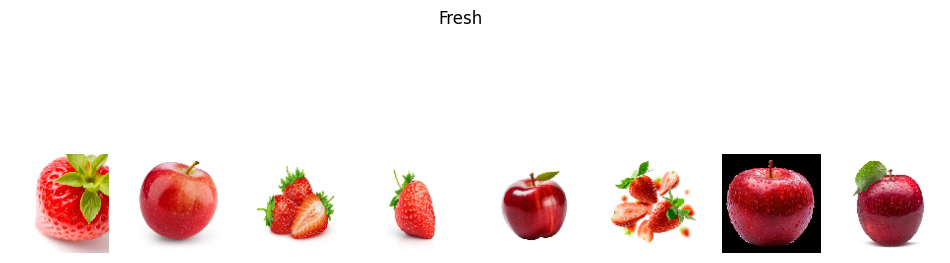

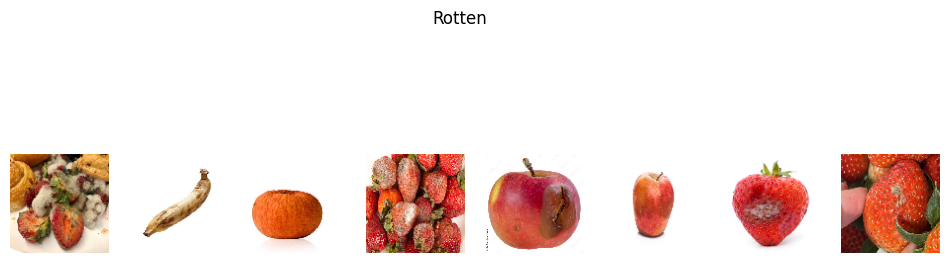

In [ ]:
# Visualize Samples
data = {"Fresh": [], "Rotten": []}
for img, label in zip(images, labels):
    data[label].append(img)

for label, imgs in data.items():
    plt.figure(figsize=(12,4))
    plt.suptitle(label)
    for i, img in enumerate(random.sample(imgs, min(8, len(imgs)))):
        plt.subplot(1,8,i+1)
        plt.imshow((img * 255).astype("uint8"))
        plt.axis("off")
    plt.show()


In [ ]:
# Encode Labels + Split Data
le = LabelEncoder()
labels_enc = le.fit_transform(labels)
labels_cat = to_categorical(labels_enc)

X_train, X_test, y_train, y_test = train_test_split(
    images, labels_cat, test_size=0.2, random_state=42, stratify=labels_cat
)


In [ ]:
# Build and Train CNN Model
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - accuracy: 0.7010 - loss: 0.8686 - val_accuracy: 0.8043 - val_loss: 0.4275
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.8456 - loss: 0.3507 - val_accuracy: 0.8261 - val_loss: 0.3509
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.8799 - loss: 0.2691 - val_accuracy: 0.7609 - val_loss: 0.4078
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step - accuracy: 0.9191 - loss: 0.2161 - val_accuracy: 0.8261 - val_loss: 0.3614
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step - accuracy: 0.9314 - loss: 0.1977 - val_accuracy: 0.8261 - val_loss: 0.3527
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.9314 - loss: 0.1518 - val_accuracy: 0.8261 - val_loss: 0.3222
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - accuracy: 0.9583 - loss: 0.1211 - val_accuracy: 0.8913 - val_loss: 0.2897
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 355ms/step - accuracy: 0.9681 - loss: 0.0935 - val_accuracy: 0.8913 - val_

In [ ]:
# Evaluate CNN Model
cnn_preds = np.argmax(cnn_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("CNN Accuracy:", accuracy_score(y_true, cnn_preds))
print(confusion_matrix(y_true, cnn_preds))


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step
CNN Accuracy: 0.956140350877193
[[76  0]
 [ 5 33]]


In [ ]:
# Prepare Data for SVM and KNN
X_flat = images.reshape(images.shape[0], -1)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_flat, labels_enc, test_size=0.2, random_state=42, stratify=labels_enc
)


In [ ]:
# Build and Train SVM Model
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_f, y_train_f)

svm_preds = svm_model.predict(X_test_f)
print("SVM Accuracy:", accuracy_score(y_test_f, svm_preds))
print(confusion_matrix(y_test_f, svm_preds))


SVM Accuracy: 0.868421052631579
[[75  1]
 [14 24]]


In [ ]:
# Build and Train KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_f, y_train_f)

knn_preds = knn_model.predict(X_test_f)
print("KNN Accuracy:", accuracy_score(y_test_f, knn_preds))
print(confusion_matrix(y_test_f, knn_preds))


KNN Accuracy: 0.8157894736842105
[[70  6]
 [15 23]]


In [ ]:
# Preprocess Single Image for Prediction
def preprocess_image(path):
    img = load_img(path, target_size=IMAGE_SIZE, color_mode='rgb')
    img = img_to_array(img) / 255.0
    return img


In [ ]:
# Predict on a Single Image
# المسار الكامل للصورة جوه المجلد بتاعك على الدرايف
test_image_path = "/content/drive/MyDrive/project 3/images.jpg"

# وبعدين كمل الكود عادي
img = preprocess_image(test_image_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


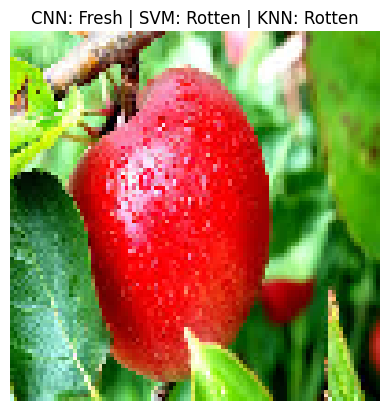

In [ ]:
# CNN
cnn_pred = le.inverse_transform([np.argmax(cnn_model.predict(img[np.newaxis,...]))])[0]

# SVM
svm_pred = le.inverse_transform(svm_model.predict(img.reshape(1,-1)))[0]

# KNN
knn_pred = le.inverse_transform(knn_model.predict(img.reshape(1,-1)))[0]

# Show result
plt.imshow((img * 255).astype("uint8"))
plt.title(f"CNN: {cnn_pred} | SVM: {svm_pred} | KNN: {knn_pred}")
plt.axis("off")
plt.show()


In [ ]:
# Predict on another Single Image
test_image_path = "/content/drive/MyDrive/project 3/images1.jpg"
img = preprocess_image(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


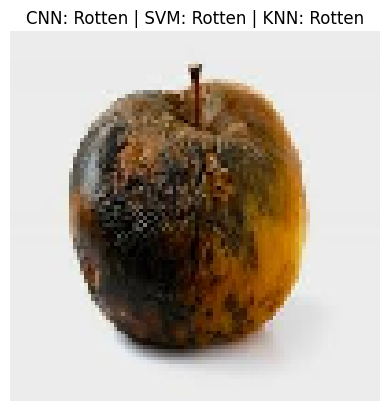

In [ ]:
# CNN
cnn_pred = le.inverse_transform([np.argmax(cnn_model.predict(img[np.newaxis,...]))])[0]

# SVM
svm_pred = le.inverse_transform(svm_model.predict(img.reshape(1,-1)))[0]

# KNN
knn_pred = le.inverse_transform(knn_model.predict(img.reshape(1,-1)))[0]

# Show result
plt.imshow((img * 255).astype("uint8"))
plt.title(f"CNN: {cnn_pred} | SVM: {svm_pred} | KNN: {knn_pred}")
plt.axis("off")
plt.show()

In [ ]:
# Predict on another Single Image
test_image_path = "/content/drive/MyDrive/project 3/test1.jpg"
img = preprocess_image(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


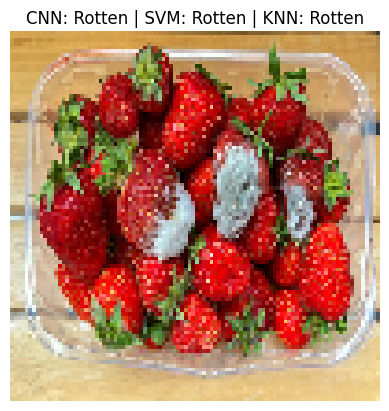

In [ ]:
# CNN
cnn_pred = le.inverse_transform([np.argmax(cnn_model.predict(img[np.newaxis,...]))])[0]

# SVM
svm_pred = le.inverse_transform(svm_model.predict(img.reshape(1,-1)))[0]

# KNN
knn_pred = le.inverse_transform(knn_model.predict(img.reshape(1,-1)))[0]

# Show result
plt.imshow((img * 255).astype("uint8"))
plt.title(f"CNN: {cnn_pred} | SVM: {svm_pred} | KNN: {knn_pred}")
plt.axis("off")
plt.show()

In [ ]:
import pickle
import google.colab.files as file
# 1. حفظ موديل الـ CNN
cnn_model.save('cnn_model_fruits.h5')
#file.download('cnn_model_fruits.h5')


# 2. حفظ موديل الـ SVM (بافتراض إن اسمه svm_model)
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

# 3. حفظ موديل الـ KNN (بافتراض إن اسمه knn_model)
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

# 4. حفظ الـ Label Encoder (عشان الأسماء تطلع صح)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ كدة معاك 4 ملفات.. نزلهم كلهم على جهازك (Download)")
from google.colab import files

# تنزيل الملفات الثلاثة المتبقية يدوياً
files.download('svm_model.pkl')
files.download('knn_model.pkl')
#files.download('label_encoder.pkl')

✅ كدة معاك 4 ملفات.. نزلهم كلهم على جهازك (Download)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>